### Step 1: Imports

# PigeonPilot — Reservoir A vs B

**Research question:** Does STDP in a recurrent LIF reservoir improve path integration
compared to a fixed (non-plastic) reservoir?

| Model | Reservoir | Readout |
|-------|-----------|---------|
| **A** | Fixed dense recurrent LIF | `RidgeClassifier` → home heading bin |
| **B** | Same init + STDP (`WeightDependentPostPre`) | same |

**Jury metric:** circular bin error × 10° (not X/Y MSE).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from IPython.display import Markdown, display
from sklearn.linear_model import RidgeClassifier

import sys
import types

# Compatibility shim for bindsnet's outdated torch._six import
import collections.abc
six_shim = types.ModuleType("torch._six")
six_shim.container_abcs = collections.abc
six_shim.string_classes = (str,)
six_shim.int_classes = (int,)
six_shim.inf = float("inf")
sys.modules["torch._six"] = six_shim

from bindsnet.network import Network
from bindsnet.network.nodes import Input, LIFNodes
from bindsnet.network.topology import Connection
from bindsnet.network.monitors import Monitor
from bindsnet.learning import WeightDependentPostPre

from pigeonpilot.paths import (
    STYLES,
    DIFFICULTIES,
    DEFAULT_HEADING_BINS,
    FULL_CIRCLE_DEG,
    Segment,
    generate_level,
    home_heading_bin,
    home_heading_deg,
)
from pigeonpilot.encoding import (
    encode_level,
    compass_bin,
    heading_to_bin,
    plan_encoding,
)
from pigeonpilot.curriculum import (
    DEFAULT_EPOCHS_PER_DIFFICULTY,
    DEFAULT_MIXED_EPOCHS_AFTER,
    curriculum_level_count,
    format_curriculum_table,
    format_style_labels_table,
    generate_curriculum_dataset,
    split_dataset,
    summarize_dataset,
    iter_train_schedule,
)
from pigeonpilot.viz import (
    plot_level,
    plot_level_encoding,
    plot_body_ring_anatomy,
    plot_level_ring_frames,
    plot_levels_grid,
    plot_release_points,
    compute_xy_limits,
    plot_spike_raster,
)

print("imports ok")
print("torch", torch.__version__)
print("trajectory families:", STYLES)
display(Markdown("### Trajectory family labels (`STYLE_LABELS`)"))
display(Markdown(format_style_labels_table()))

imports ok
torch 2.13.0
trajectory families: ('linear', 'turning', 'zigzag', 'curved')


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


### Trajectory family labels (`STYLE_LABELS`)

| Name | Meaning |
|------|---------|
| `linear` | straight / direct |
| `turning` | heading jumps (turns) |
| `zigzag` | alternating left/right zigzags |
| `curved` | wave or sweeping arc |

### Step 2: Create Dataset

In [2]:
DATASET_SEED = 42
SPLIT_SEED = 0
EXPECTED_N = curriculum_level_count()

dataset = generate_curriculum_dataset(seed=DATASET_SEED)
print(summarize_dataset(dataset))
assert len(dataset) == EXPECTED_N, f"expected {EXPECTED_N}, got {len(dataset)}"

train_set, test_set = split_dataset(dataset, train_frac=0.8, seed=SPLIT_SEED)
print(f"train: {len(train_set)} | test: {len(test_set)}")

xlim_global, ylim_global = compute_xy_limits(dataset)

# For visualization remove the comment
#
# for difficulty in DIFFICULTIES:
#     subset = [lv for lv in dataset if lv.difficulty == difficulty]
#     plot_levels_grid(subset, title=f"Difficulty: {difficulty}")
#     plt.show()

{'total': 720, 'by_difficulty': {'easy': 180, 'medium': 135, 'hard': 135, 'expert': 135, 'extreme': 135}, 'by_style': {'linear': 180, 'turning': 135, 'zigzag': 270, 'curved': 135}}
train: 573 | test: 147


### Step 3: Hyperparameters and Helper Methods

In [4]:
# --- hyperparameters ---

# --- network structure ---
N_INPUT_NODES = DEFAULT_HEADING_BINS  # number of nodes in the input layer -> 36
N_RESERVOIR_NODES = 100 # number of nodes in the reservoir
NETWORK_DT = 1.0  # 1 time unit = 1 ms (BindsNET step size)

# --- encoding (two knobs: duration via velocity, spike density via rate_hz) ---
# MUST match NETWORK_DT so one spike-matrix row = one network step.
ENCODING_DT = NETWORK_DT
# Longest path ≈ this many steps (~1 s at dt=1 ms). Raise to 5000 for a ~5 s story
# (training time scales roughly linearly with this). Paths stay the same length.
TARGET_STEPS_LONGEST = 1000
# Neural Poisson rate on the active compass bin (NOT heart rate). None = old one-hot.
INPUT_RATE_HZ = 40.0
# Base seed for Poisson; per-level seed = ENCODING_SEED + level.level_id (reproducible).
ENCODING_SEED = 0
TRAILING_SILENCE = 20  # zeros after the path so the reservoir can settle

# Same speed for every route: calibrate so max path distance → TARGET_STEPS_LONGEST.
_max_dist = max(sum(s.distance for s in lv.segments) for lv in dataset)
ENCODING_VELOCITY = _max_dist / (TARGET_STEPS_LONGEST * ENCODING_DT)

# --- weight initialization ---
WEIGHT_SEED = 0
# FEEDFORWARD_SCALE = 0.8
FEEDFORWARD_STRENGTH = 50 # normalization constant - the total strength that will go into the reservoir
RESERVOIR_SCALE = 0.9  # scaling constant for the recurrent connections in the reservoir
WMIN, WMAX = 0.0, 10.0  # feedforward connection clamp (weights are always >= 0)

# --- inhibitory weights ---
INHIB_FRACTION = 0.2       # 20 percent of connections in the reservoir are inhibitory
INHIB_WEIGHT_RATIO = 1.0   # inhibitory synapses are this many times stronger than excitatory
RESERVOIR_WMIN, RESERVOIR_WMAX = -WMAX, WMAX # connection clamp for the reservoir (inhibitory weights are negative)

# --- learning parameters ---
# tc_decay = τ_m (ms): membrane echo; recurrence extends memory further across the flight.
LIF_KW = dict(rest=-65.0, reset=-65.0, thresh=-52.0, refrac=5, tc_decay=250.0)
STDP_NU =(1e-3, 1e-3)  # learning rate for STDP
STDP_TC_PRE = 20.0 # pre-synaptic trace time constant of 20 ms for STDP
STDP_TC_POST = 20.0 # post-synaptic trace time constant of 20 ms for STDP

# Plasticity: few epochs on easy (avoid +180 shortcut); mixed rehearsal after ladder
STDP_EPOCHS_PER_DIFFICULTY = dict(DEFAULT_EPOCHS_PER_DIFFICULTY)
STDP_MIXED_EPOCHS_AFTER = DEFAULT_MIXED_EPOCHS_AFTER

# --- readout function: Ridge Regression ---
RIDGE_ALPHA = 0.01

def home_bin(level, heading_bins: int = DEFAULT_HEADING_BINS) -> int:
    """Classification label: heading bin of home_xy (package SSOT)."""
    return home_heading_bin(level, heading_bins)


def circular_bin_error(
    true_bin: int,
    pred_bin: int,
    heading_bins: int = DEFAULT_HEADING_BINS,
) -> tuple[int, float]:
    """Return (bin_error, degrees)."""
    d = abs(int(true_bin) - int(pred_bin)) % heading_bins
    d = min(d, heading_bins - d)
    return d, d * (FULL_CIRCLE_DEG / heading_bins)


def encode_level_for_network(level) -> np.ndarray:
    # Duration from velocity/dt; Poisson density from rate_hz; seed = base + level_id for repro.
    spikes = encode_level(
        level,
        velocity=ENCODING_VELOCITY,
        dt=ENCODING_DT,
        heading_bins=N_INPUT_NODES,
        rate_hz=INPUT_RATE_HZ,
        seed=ENCODING_SEED + int(level.level_id),
    )
    if TRAILING_SILENCE > 0:
        pad = np.zeros((TRAILING_SILENCE, N_INPUT_NODES), dtype=np.float32)
        spikes = np.vstack([spikes, pad])
    return spikes


def to_bindsnet_input(spikes: np.ndarray) -> torch.Tensor:
    # Converts the already computed spike input from a numpy array into a torch tensor
    return torch.from_numpy(np.asarray(spikes, dtype=np.float32)).unsqueeze(1)

def pool_reservoir_state(spike_tensor: torch.Tensor) -> np.ndarray:
    # retrieves the mean firing rate of each reservoir neuron across the entire trial
    return spike_tensor.float().mean(dim=0).squeeze(0).detach().cpu().numpy()

def run_trial(net: Network, level, learning: bool) -> np.ndarray:
    """Encode → run → pool state → reset. Returns pooled reservoir rates."""
    spikes = encode_level_for_network(level) # encodes the raw x,y coordinates of the level into spikes of 36 neurons where each spikes when its assigned position is pointed northwards. Math for this calculation is in encoding.py and paths.py
    inputs = to_bindsnet_input(spikes) # convert from numpy array to torch tensor
    net.train(learning) # toggles plasticity on or off
    net.run(inputs={"Input": inputs}, time=spikes.shape[0]) # gives the input to the network and lets it run
    state = pool_reservoir_state(net.monitors["Reservoir Spikes"].get("s")) # gets the mean firing rate of each reservoir neuron from the monitoring
    net.reset_state_variables() # resets the state of the network (learned weights stay)
    return state


# Sanity: South home ≈ bin 18; pred bin 19 → 1 bin = 10°
_south = generate_level(
    style="linear", n_segments=1, seed=0, base_heading_deg=0.0, distance_range=(1.0, 1.0)
)
assert abs(home_heading_deg(_south.home_xy) - 180.0) < 1e-6
assert home_bin(_south) == 18, home_bin(_south)
bins_err, deg_err = circular_bin_error(18, 19)
assert bins_err == 1 and deg_err == 10.0, (bins_err, deg_err)
print(
    "helpers ok |",
    f"dt={ENCODING_DT}",
    f"| v={ENCODING_VELOCITY:.4f}",
    f"| target_T={TARGET_STEPS_LONGEST}",
    f"| rate_hz={INPUT_RATE_HZ}",
    f"| max_dist={_max_dist:.2f}",
    f"| silence={TRAILING_SILENCE}",
)
print("example train home_bin:", home_bin(train_set[0]), "heading°:", round(home_heading_deg(train_set[0].home_xy), 1))

helpers ok | dt=1.0 | v=0.0091 | target_T=1000 | rate_hz=40.0 | max_dist=9.15 | silence=20
example train home_bin: 18 heading°: 180.0


### Step 4: Build 2 Networks
`network_a` without plasticity and `network_b` with plasticity

In [5]:
from bindsnet import network
import collections.abc


def init_weights(n_input: int, n_res: int, seed: int = WEIGHT_SEED):
    # n_input: number of input neurons
    # n_res: number of reservoir neurons
    # seed: random seed

    generator = torch.Generator().manual_seed(seed)

    # Initializing feedforward weights
    feedforward_weights = torch.rand(n_input, n_res, generator=generator)
    normalized_feedforward_weights = FEEDFORWARD_STRENGTH * feedforward_weights / feedforward_weights.sum(dim=0, keepdim=True)

    # Initializing reservoir weights
    reservoir_weights = torch.rand(n_res, n_res, generator=generator)
    reservoir_weights.fill_diagonal_(0.0) # removes self connections

    # make a fraktion of the reservoir weights inhibitory = negative - Dale's Law
    n_inhibitory = int(round(INHIB_FRACTION * n_res))
    inhibitory_idx = torch.randperm(n_res, generator=generator)[:n_inhibitory]
    reservoir_weights[inhibitory_idx, :] *= -INHIB_WEIGHT_RATIO

    # Spectral radius = largest eigenvalue of the recurrent weight matrix.
    # It controls whether signals grow (>1), decay (<1), or persist (~1) as they
    # loop through the reservoir, so we rescale the matrix to hit the target value RESERVOIR_SCALE.
    spectral_radius = torch.linalg.eigvals(reservoir_weights).abs().max().item() # Spectral radius control to
    scaled_reservoir_weights = reservoir_weights * (RESERVOIR_SCALE / spectral_radius)

    return normalized_feedforward_weights, scaled_reservoir_weights


def build_reservoir(
    *,
    plastic: bool,
    w_ff: torch.Tensor,
    w_res: torch.Tensor,
    dt: float = NETWORK_DT,
) -> Network:
    # Builds a reservoir network
    # plastic: if set to true, it will add plasticity with STDP
    # w_ff: Initial Feedforward weights
    # w_res: Initial recurrent Reservoir weights
    # dt: simulation step size
    n_input, n_res = w_ff.shape
    assert w_res.shape == (n_res, n_res)

    network = Network(dt=dt)
    input_layer = Input(n=n_input, traces=True)
    reservoir = LIFNodes(n=n_res, traces=True, **LIF_KW) # **LIF_KW uses the earlier declared values from LIF_KW = ...
    network.add_layer(input_layer, name="Input")
    network.add_layer(reservoir, name="Reservoir")

    feedforward_conn_kwargs = dict(wmin=WMIN, wmax=WMAX)
    # Recurrent connection now carries negative (inhibitory) weights after the
    # Dale's-law split in init_weights(), so it needs its own symmetric clamp
    # instead of WMIN/WMAX (which would zero out every inhibitory weight).
    recurrent_conn_kwargs = dict(wmin=RESERVOIR_WMIN, wmax=RESERVOIR_WMAX)

    # If plastic = true, we want to add STDP parameters
    if plastic:
        stdp_kwargs = dict(
            update_rule=WeightDependentPostPre,
            nu=STDP_NU,
            tc_pre=STDP_TC_PRE,
            tc_post=STDP_TC_POST,
        )
        feedforward_conn_kwargs.update(stdp_kwargs)
        recurrent_conn_kwargs.update(stdp_kwargs)

    feedforward_connection = Connection(
        source=input_layer,
        target=reservoir,
        w=w_ff.clone(),
        **feedforward_conn_kwargs,
    )
    reservoir_connection = Connection(
        source=reservoir,
        target=reservoir,
        w=w_res.clone(),
        **recurrent_conn_kwargs,
    )
    network.add_connection(feedforward_connection, source="Input", target="Reservoir")
    network.add_connection(reservoir_connection, source="Reservoir", target="Reservoir")

    network.add_monitor(
        Monitor(obj=reservoir, state_vars=["s"], time=None),
        name="Reservoir Spikes",
    )
    return network


initial_feedforward_weights, initial_reservoir_weights = init_weights(N_INPUT_NODES, N_RESERVOIR_NODES, seed=WEIGHT_SEED)
network_a = build_reservoir(plastic=False, w_ff=initial_feedforward_weights, w_res=initial_reservoir_weights)
network_b = build_reservoir(plastic=True, w_ff=initial_feedforward_weights, w_res=initial_reservoir_weights)

# identical start weights
assert torch.allclose(
    network_a.connections[("Input", "Reservoir")].w,
    network_b.connections[("Input", "Reservoir")].w,
)
assert torch.allclose(
    network_a.connections[("Reservoir", "Reservoir")].w,
    network_b.connections[("Reservoir", "Reservoir")].w,
)
assert torch.count_nonzero(
    torch.diag(network_a.connections[("Reservoir", "Reservoir")].w)
) == 0

print(network_a)
print("A plastic rules:", {k: c.update_rule for k, c in network_a.connections.items()})
print("B plastic rules:", {k: type(c.update_rule).__name__ if c.update_rule else None for k, c in network_b.connections.items()})
print("w_ff mean", float(initial_feedforward_weights.mean()), "| w_rec mean (off-diag)", float(initial_reservoir_weights[~torch.eye(N_RESERVOIR_NODES, dtype=bool)].mean()))

Network(
  (Input): Input()
  (Reservoir): LIFNodes()
  (Input_to_Reservoir): Connection(
    (source): Input()
    (target): LIFNodes()
  )
  (Reservoir_to_Reservoir): Connection(
    (source): LIFNodes()
    (target): LIFNodes()
  )
)
A plastic rules: {('Input', 'Reservoir'): <bindsnet.learning.learning.NoOp object at 0x138cc8830>, ('Reservoir', 'Reservoir'): <bindsnet.learning.learning.NoOp object at 0x10ac8e990>}
B plastic rules: {('Input', 'Reservoir'): 'WeightDependentPostPre', ('Reservoir', 'Reservoir'): 'WeightDependentPostPre'}
w_ff mean 1.3888888359069824 | w_rec mean (off-diag) 0.009431671351194382


smoke level_id=0 T=199 home_bin=18 res_spikes=18 active=18/100


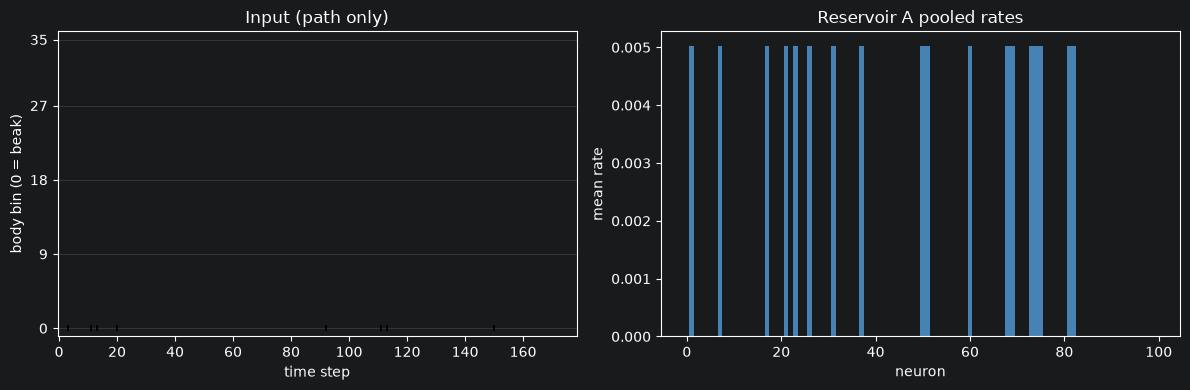

smoke level_id=1 T=277 home_bin=19 res_spikes=40 active=38/100


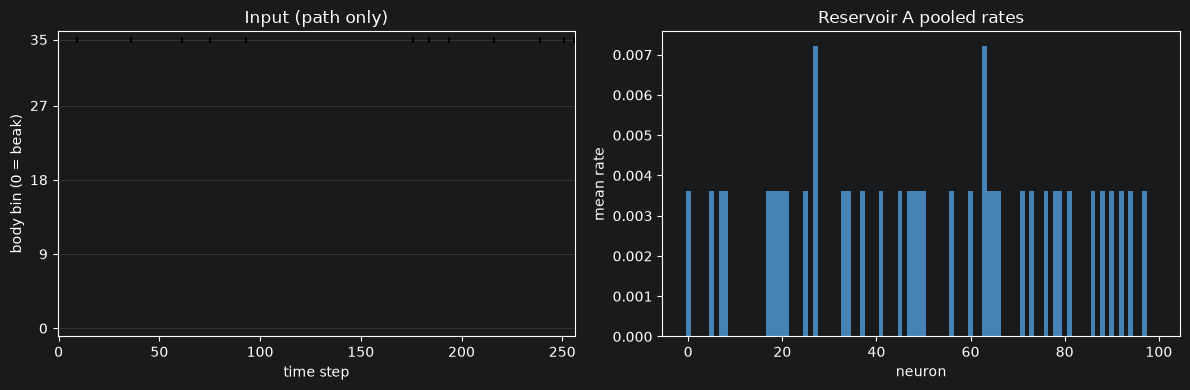

smoke level_id=2 T=287 home_bin=20 res_spikes=14 active=14/100


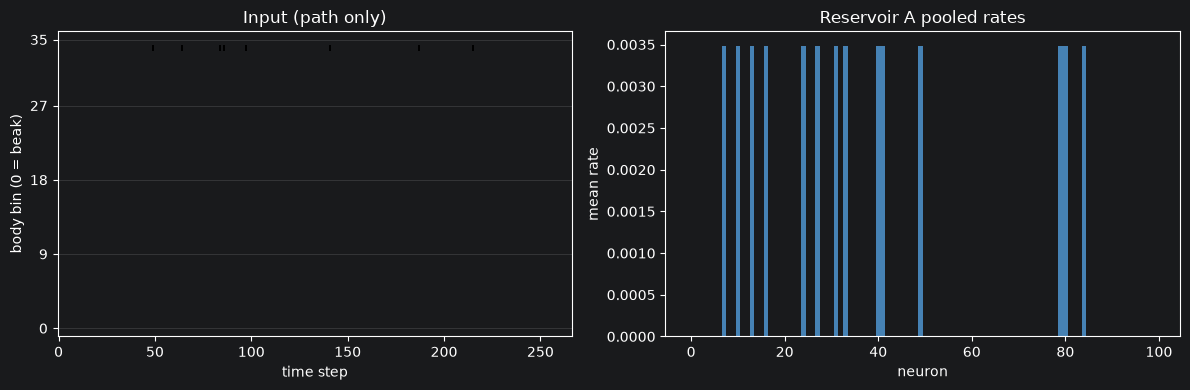

smoke level_id=5 T=298 home_bin=23 res_spikes=39 active=39/100


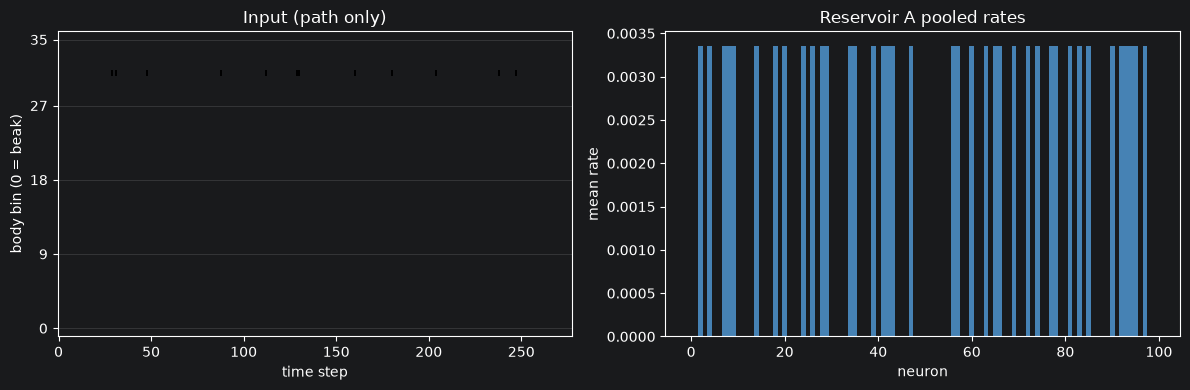

smoke level_id=6 T=353 home_bin=24 res_spikes=0 active=0/100


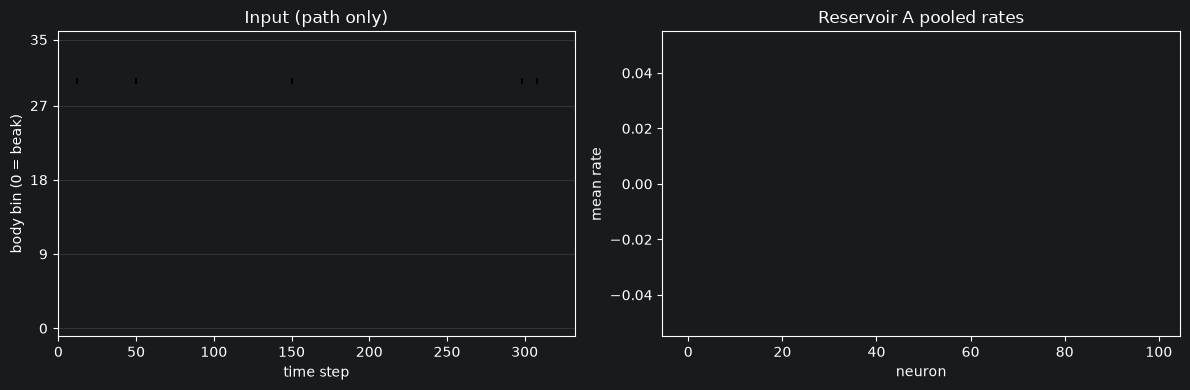

smoke level_id=7 T=422 home_bin=25 res_spikes=91 active=61/100


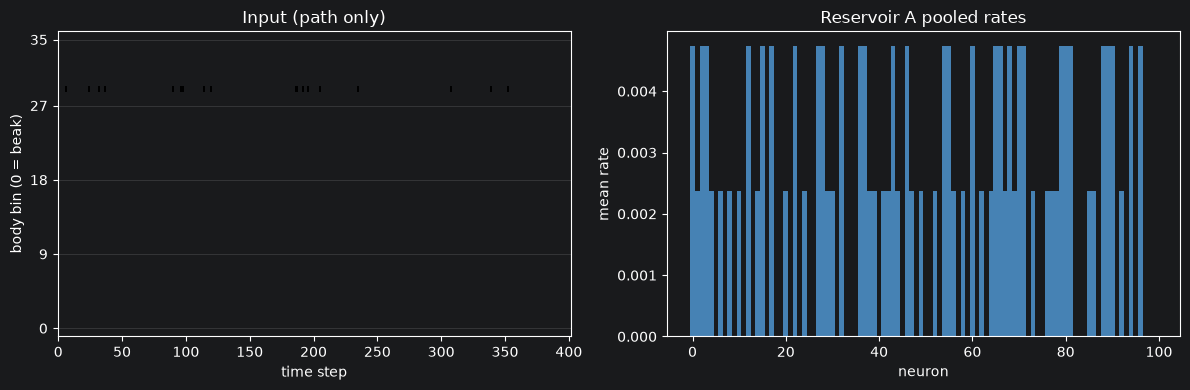

smoke level_id=8 T=244 home_bin=26 res_spikes=8 active=8/100


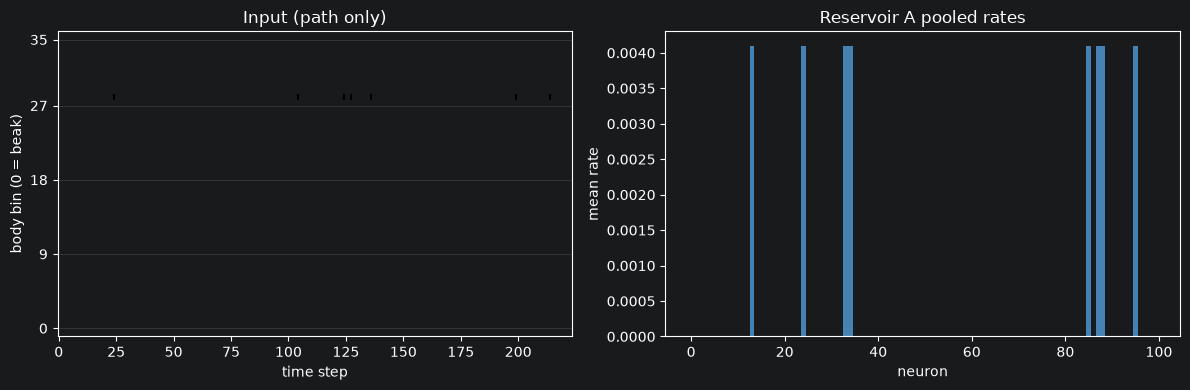

smoke level_id=9 T=419 home_bin=27 res_spikes=21 active=21/100


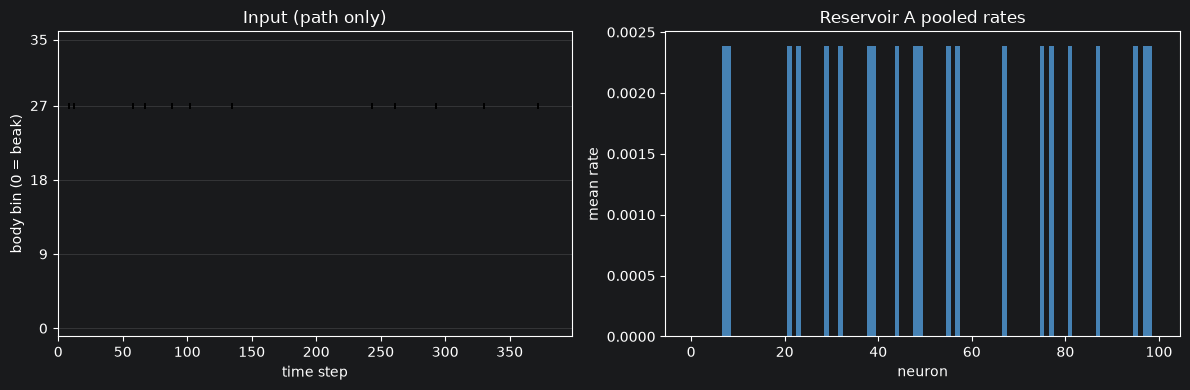

smoke level_id=10 T=303 home_bin=28 res_spikes=0 active=0/100


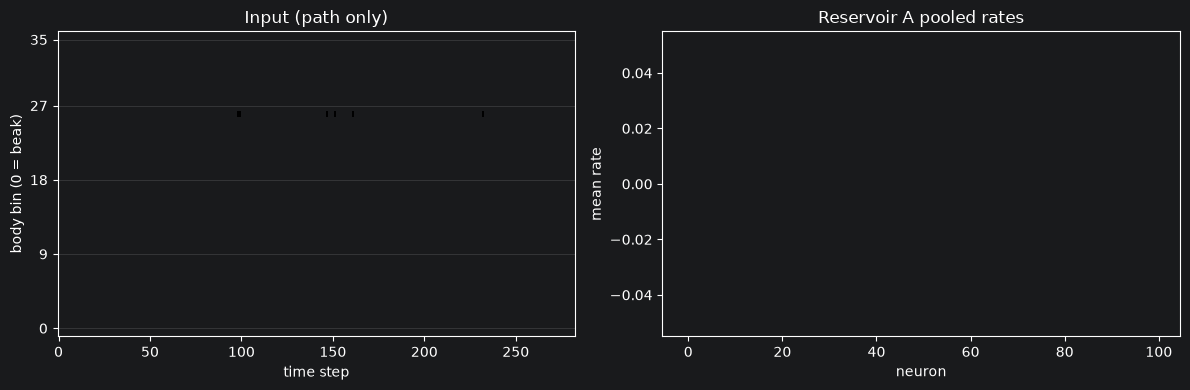

smoke ok
mean active neurons:0.22111111111111115


In [6]:
easy_levels = [lv for lv in train_set if lv.difficulty == "easy"][:10]
activities = []
for smoke_level in easy_levels:
    if smoke_level.level_id == 3: continue
    smoke_spikes = encode_level_for_network(smoke_level)
    smoke_input = to_bindsnet_input(smoke_spikes)
    T_smoke = smoke_spikes.shape[0]

    network_a.train(False)
    network_a.run(inputs={"Input": smoke_input}, time=T_smoke)
    s_a = network_a.monitors["Reservoir Spikes"].get("s")
    state_a = pool_reservoir_state(s_a)
    print(
        f"smoke level_id={smoke_level.level_id} T={T_smoke} "
        f"home_bin={home_bin(smoke_level)} "
        f"res_spikes={float(s_a.sum()):.0f} "
        f"active={(state_a > 0).sum()}/{N_RESERVOIR_NODES}"
    )
    activities.append((state_a > 0).sum()/N_RESERVOIR_NODES)
   # assert s_a.sum() > 0, "Reservoir A produced no spikes — raise FF_SCALE or ENCODING length"

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_spike_raster(smoke_spikes[: max(1, T_smoke - TRAILING_SILENCE)], ax=axes[0], title="Input (path only)")
    axes[1].bar(np.arange(N_RESERVOIR_NODES), state_a, width=1.0, color="steelblue")
    axes[1].set_title("Reservoir A pooled rates")
    axes[1].set_xlabel("neuron")
    axes[1].set_ylabel("mean rate")
    plt.tight_layout()
    plt.show()

    network_a.reset_state_variables()
print("smoke ok")
print(f"mean active neurons:{sum(activities) / len(activities)}")

### Step 5: Smoke-test one easy level
feed one level to Network A and monitor the output of the reservoir neurons

### Step 6: STDP
Introduce plasticity to Network B

In [8]:
feedforward_weights_before = network_b.connections[("Input", "Reservoir")].w.detach().clone()
reservoir_weights_before = network_b.connections[("Reservoir", "Reservoir")].w.detach().clone()

current_trial = 0
print("STDP Curriculum - epochs per difficulty:", STDP_EPOCHS_PER_DIFFICULTY)
print("STDP mixed rehearsal after ladder:", STDP_MIXED_EPOCHS_AFTER)

# Skill ladder easy→extreme, then short mixed rehearsal against forgetting.
for phase, phase_epoch, _, level in iter_train_schedule(
    train_set,
    mode="curriculum",
    epochs_per_difficulty=STDP_EPOCHS_PER_DIFFICULTY,
    n_epochs_mixed_after=STDP_MIXED_EPOCHS_AFTER,
    seed=0,
):
    # phase — difficulty name or "mixed"
    # phase_epoch — epoch within the current phase
    # level — Level presented this trial
    run_trial(network_b, level, learning=True)
    current_trial += 1
    if current_trial % 100 == 0:
        print(f"  ... {current_trial} plastic trials (phase={phase}, epoch={phase_epoch})")

network_b.train(False)

feedforward_weights_after = network_b.connections[("Input", "Reservoir")].w.detach()
reservoir_weights_after = network_b.connections[("Reservoir", "Reservoir")].w.detach()
ff_delta = float((feedforward_weights_after - feedforward_weights_before).abs().mean())
rec_delta = float((reservoir_weights_after - reservoir_weights_before).abs().mean())
print(f"plastic trials: {current_trial}")
print(f"mean |Δw| FF={ff_delta:.6f}  Rec={rec_delta:.6f}")
assert ff_delta > 0 or rec_delta > 0, "STDP did not change weights"
print("Model B frozen for readout")

STDP Curriculum - epochs per difficulty: {'easy': 3, 'medium': 3, 'hard': 3, 'expert': 3, 'extreme': 3}
STDP mixed rehearsal after ladder: 6
  ... 100 plastic trials (phase=easy, epoch=0)
  ... 200 plastic trials (phase=easy, epoch=1)
  ... 300 plastic trials (phase=easy, epoch=2)
  ... 400 plastic trials (phase=easy, epoch=2)
  ... 500 plastic trials (phase=medium, epoch=0)
  ... 600 plastic trials (phase=medium, epoch=1)
  ... 700 plastic trials (phase=medium, epoch=2)
  ... 800 plastic trials (phase=hard, epoch=0)
  ... 900 plastic trials (phase=hard, epoch=1)
  ... 1000 plastic trials (phase=hard, epoch=2)
  ... 1100 plastic trials (phase=expert, epoch=0)
  ... 1200 plastic trials (phase=expert, epoch=1)
  ... 1300 plastic trials (phase=expert, epoch=2)
  ... 1400 plastic trials (phase=extreme, epoch=0)
  ... 1500 plastic trials (phase=extreme, epoch=0)
  ... 1600 plastic trials (phase=extreme, epoch=1)
  ... 1700 plastic trials (phase=extreme, epoch=2)
  ... 1800 plastic trials (p

### Step 7: Collect states + fit RidgeClassifier (A and B)

Target = `home_bin(level)` ∈ {0…35}.

In [9]:
def collect_states(net: Network, levels) -> tuple[np.ndarray, np.ndarray, list]:
    # runs the network on all levels in the set returning 3 lists:
    # X: the reservoir firing, y: the correct label as the bin in the home direction, difficulties: the difficulty of the level
    X, y, difficulties = [], [], []
    for i, level in enumerate(levels):
        state = run_trial(net, level, learning=False)
        X.append(state)
        y.append(home_bin(level))
        difficulties.append(level.difficulty)
        if (i + 1) % 40 == 0:
            print(f"  collected {i + 1}/{len(levels)}")
    return np.asarray(X, dtype=np.float64), np.asarray(y, dtype=np.int64), difficulties


print("Collecting train states — Model A")
X_train_a, y_train_a, train_diffs = collect_states(network_a, train_set)
print("Collecting train states — Model B")
X_train_b, y_train_b, _ = collect_states(network_b, train_set)

print("Collecting test states — Model A")
X_test_a, y_test_a, test_diffs = collect_states(network_a, test_set)
print("Collecting test states — Model B")
X_test_b, y_test_b, _ = collect_states(network_b, test_set)

assert np.array_equal(y_train_a, y_train_b)
assert np.array_equal(y_test_a, y_test_b)
print("unique train bins:", len(np.unique(y_train_a)), "/ 36")

# Joint readout (jury): fit on all train difficulties
classifier_a = RidgeClassifier(alpha=RIDGE_ALPHA)
classifier_b = RidgeClassifier(alpha=RIDGE_ALPHA)
classifier_a.fit(X_train_a, y_train_a)
classifier_b.fit(X_train_b, y_train_b)
print("Joint RidgeClassifiers fitted")


  collected 40/573
  collected 80/573
  collected 120/573
  collected 160/573
  collected 200/573
  collected 240/573
  collected 280/573
  collected 320/573
  collected 360/573
  collected 400/573
  collected 440/573
  collected 480/573
  collected 520/573
  collected 560/573
  collected 40/573
  collected 80/573
  collected 120/573
  collected 160/573
  collected 200/573
  collected 240/573
  collected 280/573
  collected 320/573
  collected 360/573
  collected 400/573
  collected 440/573
  collected 480/573
  collected 520/573
  collected 560/573
  collected 40/147
  collected 80/147
  collected 120/147
  collected 40/147
  collected 80/147
  collected 120/147
unique train bins: 36 / 36
Joint RidgeClassifiers fitted


### Step 8: Evaluation — circular angular error

In [11]:
def angular_errors(y_true: np.ndarray, y_pred: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    # calculates the error between prediction and true value in a circular disctance, because 10 degrees is close to 350 degrees
    bins_err = np.empty(len(y_true), dtype=np.int64)
    degrees_err = np.empty(len(y_true), dtype=np.float64)
    for i, (true_value, predicted_value) in enumerate(zip(y_true, y_pred)):
        bin_error, direction_error = circular_bin_error(int(true_value), int(predicted_value))
        bins_err[i] = bin_error
        degrees_err[i] = direction_error
    return bins_err, degrees_err

# predictions of both models on the test set
pred_a = classifier_a.predict(X_test_a)
pred_b = classifier_b.predict(X_test_b)

# errors of both models on the test set in bins and degrees
bins_error_a, degrees_error_a = angular_errors(y_test_a, pred_a)
bins_error_b, degrees_error_b = angular_errors(y_test_b, pred_b)

# accuracy - how many were correctly guessed - of both models on the test set
accuracy_a = float((pred_a == y_test_a).mean())
accuracy_b = float((pred_b == y_test_b).mean())

summary = {
    "A": {"mean_deg": float(degrees_error_a.mean()), "std_deg": float(degrees_error_a.std()), "exact_acc": accuracy_a},
    "B": {"mean_deg": float(degrees_error_b.mean()), "std_deg": float(degrees_error_b.std()), "exact_acc": accuracy_b},
}

print("=== Test angular error (circular) ===")
print(
    f"Pigeon A (fixed):  mean error {summary['A']['mean_deg']:.1f}° ± {summary['A']['std_deg']:.1f}°  "
    f"| exact-bin acc {100 * accuracy_a:.1f}%"
)
print(
    f"Pigeon B (STDP):   mean error {summary['B']['mean_deg']:.1f}° ± {summary['B']['std_deg']:.1f}°  "
    f"| exact-bin acc {100 * accuracy_b:.1f}%"
)

print("\nBy difficulty (mean °):")
for diff in DIFFICULTIES:
    mask = np.array([d == diff for d in test_diffs])
    if not mask.any():
        continue
    print(
        # n is the number of tests for the specific difficulty
        f"  {diff:8s}  A={degrees_error_a[mask].mean():5.1f}°   B={degrees_error_b[mask].mean():5.1f}°   n={mask.sum()}"
    )

=== Test angular error (circular) ===
Pigeon A (fixed):  mean error 35.7° ± 34.2°  | exact-bin acc 23.1%
Pigeon B (STDP):   mean error 68.6° ± 55.6°  | exact-bin acc 13.6%

By difficulty (mean °):
  easy      A= 24.4°   B= 60.8°   n=36
  medium    A= 32.1°   B= 48.2°   n=28
  hard      A= 21.9°   B= 76.5°   n=26
  expert    A= 43.4°   B= 75.9°   n=29
  extreme   A= 58.6°   B= 84.3°   n=28


### Step 9: Jury comparison plots
- Diagram 1 shows the overall mean angular error of both networks
- Diagram 2 shows in how many tests (y-axis) each network was off by how many degrees (x-axis)
- Diagram 3 shows the mean error of both networks per level difficulty

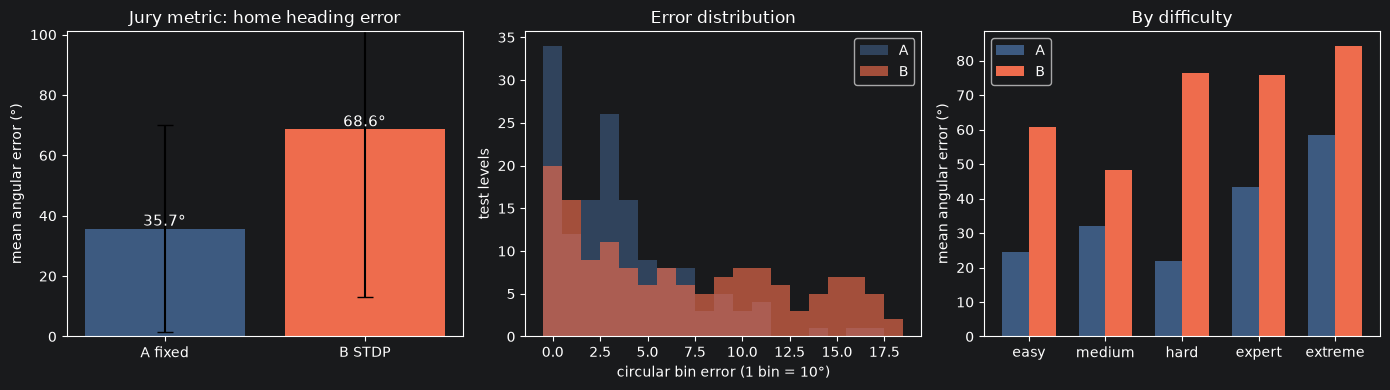

Headline: Pigeon A 36° vs Pigeon B 69° → better: A (fixed)
Interpretation: STDP may overwrite the reservoir's fading short-term memory.


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1) Mean angular error bar
ax = axes[0]
means = [summary["A"]["mean_deg"], summary["B"]["mean_deg"]]
stds = [summary["A"]["std_deg"], summary["B"]["std_deg"]]
bars = ax.bar(["A fixed", "B STDP"], means, yerr=stds, color=["#3d5a80", "#ee6c4d"], capsize=6)
ax.set_ylabel("mean angular error (°)")
ax.set_title("Jury metric: home heading error")
ax.set_ylim(0, max(means) * 1.4 + 5)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, m + 1, f"{m:.1f}°", ha="center", fontsize=11)

# 2) Histogram of bin errors
ax = axes[1]
max_bin = max(int(bins_error_a.max()), int(bins_error_b.max()), 1)
bins_edges = np.arange(0, max_bin + 2) - 0.5
ax.hist(bins_error_a, bins=bins_edges, alpha=0.65, label="A", color="#3d5a80")
ax.hist(bins_error_b, bins=bins_edges, alpha=0.65, label="B", color="#ee6c4d")
ax.set_xlabel("circular bin error (1 bin = 10°)")
ax.set_ylabel("test levels")
ax.set_title("Error distribution")
ax.legend()

# 3) Per-difficulty means
ax = axes[2]
x = np.arange(len(DIFFICULTIES))
width = 0.35
means_a_d, means_b_d = [], []
for diff in DIFFICULTIES:
    mask = np.array([d == diff for d in test_diffs])
    means_a_d.append(float(degrees_error_a[mask].mean()) if mask.any() else 0.0)
    means_b_d.append(float(degrees_error_b[mask].mean()) if mask.any() else 0.0)
ax.bar(x - width / 2, means_a_d, width, label="A", color="#3d5a80")
ax.bar(x + width / 2, means_b_d, width, label="B", color="#ee6c4d")
ax.set_xticks(x)
ax.set_xticklabels(DIFFICULTIES)
ax.set_ylabel("mean angular error (°)")
ax.set_title("By difficulty")
ax.legend()

plt.tight_layout()
plt.show()

winner = "A (fixed)" if summary["A"]["mean_deg"] <= summary["B"]["mean_deg"] else "B (STDP)"
print(
    f"Headline: Pigeon A {summary['A']['mean_deg']:.0f}° vs Pigeon B {summary['B']['mean_deg']:.0f}° "
    f"→ better: {winner}"
)
if summary["A"]["mean_deg"] < summary["B"]["mean_deg"]:
    print("Interpretation: STDP may overwrite the reservoir's fading short-term memory.")
else:
    print("Interpretation: STDP appears to help (or not hurt) path-integration readout.")

### Step 10: Staged progressive readout (per-difficulty, cumulative)

Train on difficulties `1..k` (curriculum order: easy → medium → hard → expert → extreme),
then evaluate the resulting classifier **separately** on each of those `k` difficulties'
test levels — not blended into one number. So stage 1 gives 1 result row (easy tested on
easy), stage 2 gives 2 rows (easy and medium each tested on their own), stage 3 gives 3
rows, etc. This is a different question than Step 7/8/9's joint readout above (which
trains once on everything and reports one overall number) — it shows how the readout's
per-difficulty performance evolves as more training difficulties get added, and whether
adding harder difficulties helps or hurts what was already learned on easier ones.

Reuses the same `X_train_a/b`, `X_test_a/b` states from Step 7 — no need to retrain the
reservoirs, only the readout classifier changes here.

In [13]:
train_diffs_arr = np.asarray(train_diffs)
test_diffs_arr = np.asarray(test_diffs)


def _mean_deg(y_true, y_pred):
    errs = [circular_bin_error(int(t), int(p))[1] for t, p in zip(y_true, y_pred)]
    return float(np.mean(errs))


staged_results = []  # one row per (train_stage, test_difficulty)

for k in range(len(DIFFICULTIES)):
    included = DIFFICULTIES[: k + 1]  # difficulties trained on so far, in curriculum order
    tr_mask = np.array([d in included for d in train_diffs_arr])
    if not tr_mask.any():
        continue

    clf_a_k = RidgeClassifier(alpha=RIDGE_ALPHA).fit(X_train_a[tr_mask], y_train_a[tr_mask])
    clf_b_k = RidgeClassifier(alpha=RIDGE_ALPHA).fit(X_train_b[tr_mask], y_train_b[tr_mask])

    # Evaluate on EACH included difficulty separately, not blended together
    for test_diff in included:
        te_mask = test_diffs_arr == test_diff
        if not te_mask.any():
            continue
        pred_a_k = clf_a_k.predict(X_test_a[te_mask])
        pred_b_k = clf_b_k.predict(X_test_b[te_mask])
        staged_results.append(
            {
                "train_stage": k + 1,
                "train_included": " + ".join(included),
                "test_difficulty": test_diff,
                "n": int(te_mask.sum()),
                "a_deg": _mean_deg(y_test_a[te_mask], pred_a_k),
                "a_acc": float((pred_a_k == y_test_a[te_mask]).mean()),
                "b_deg": _mean_deg(y_test_b[te_mask], pred_b_k),
                "b_acc": float((pred_b_k == y_test_b[te_mask]).mean()),
            }
        )

print("Staged progressive readout — train on difficulties 1..k, test on EACH included difficulty separately:\n")
header = (
    f"{'stage':>5} | {'trained on':<40} | {'tested on':<8} | {'n':>4} | "
    f"{'A °':>6} | {'A acc':>6} | {'B °':>6} | {'B acc':>6}"
)
print(header)
print("-" * len(header))
for row in staged_results:
    print(
        f"{row['train_stage']:>5} | {row['train_included']:<40} | {row['test_difficulty']:<8} | "
        f"{row['n']:>4} | {row['a_deg']:>6.1f} | {row['a_acc']:>6.1%} | {row['b_deg']:>6.1f} | {row['b_acc']:>6.1%}"
    )

Staged progressive readout — train on difficulties 1..k, test on EACH included difficulty separately:

stage | trained on                               | tested on |    n |    A ° |  A acc |    B ° |  B acc
-------------------------------------------------------------------------------------------------------
    1 | easy                                     | easy     |   36 |   23.6 |  75.0% |   33.9 |  63.9%
    2 | easy + medium                            | easy     |   36 |   22.8 |  69.4% |   60.0 |  36.1%
    2 | easy + medium                            | medium   |   28 |   25.4 |  14.3% |   47.1 |  10.7%
    3 | easy + medium + hard                     | easy     |   36 |   22.2 |  69.4% |   47.2 |  38.9%
    3 | easy + medium + hard                     | medium   |   28 |   30.7 |  10.7% |   46.8 |   7.1%
    3 | easy + medium + hard                     | hard     |   26 |   31.2 |  11.5% |   64.6 |  11.5%
    4 | easy + medium + hard + expert            | easy     |   36 |   

### Step 11: Staged readout plots

For each difficulty, plot its held-out error starting from the stage it was first
trained on, continuing through every later stage — one line per difficulty, one panel
per model (A vs B). A rising line means adding more (harder) training difficulties is
hurting a difficulty that was already learned (forgetting); a flat or falling line means
it isn't.

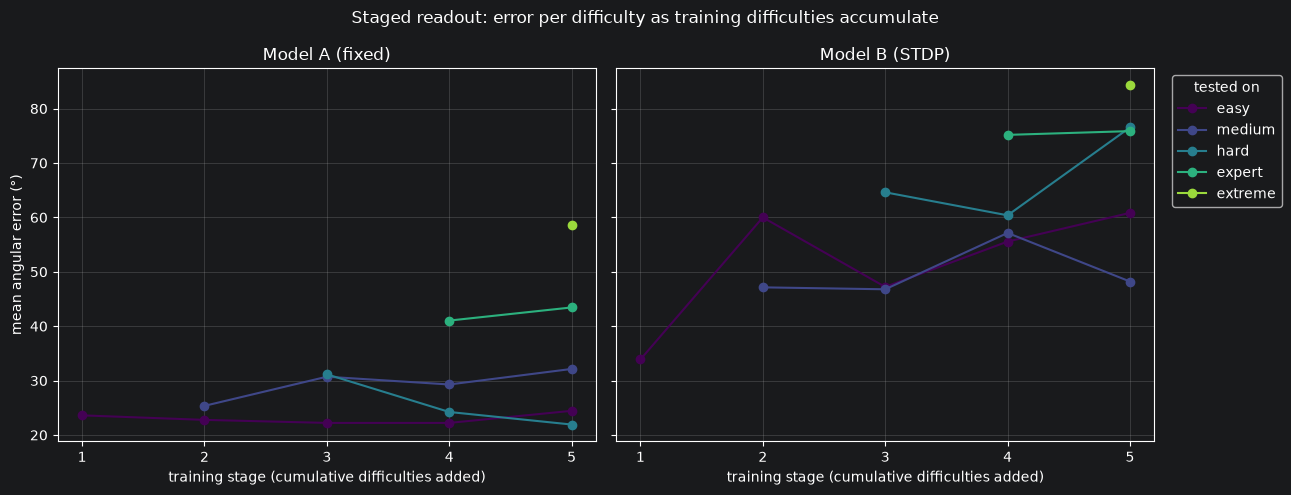

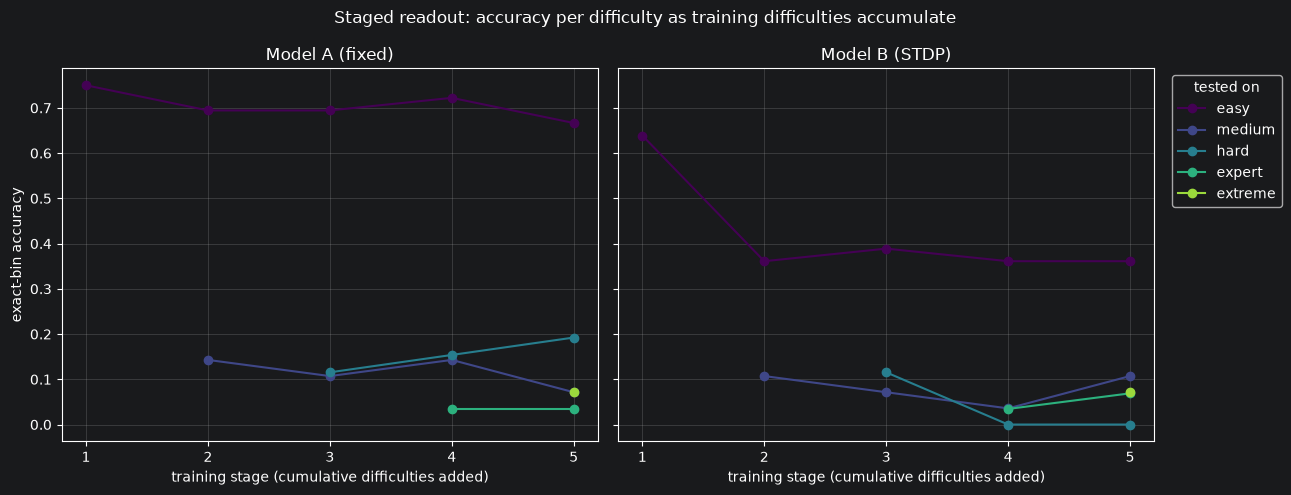

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

colors = plt.cm.viridis(np.linspace(0, 0.85, len(DIFFICULTIES)))
color_by_diff = dict(zip(DIFFICULTIES, colors))

for ax, model_key, title in [(axes[0], "a_deg", "Model A (fixed)"), (axes[1], "b_deg", "Model B (STDP)")]:
    for diff in DIFFICULTIES:
        stages = [r["train_stage"] for r in staged_results if r["test_difficulty"] == diff]
        values = [r[model_key] for r in staged_results if r["test_difficulty"] == diff]
        if not stages:
            continue
        ax.plot(stages, values, marker="o", label=diff, color=color_by_diff[diff])
    ax.set_xlabel("training stage (cumulative difficulties added)")
    ax.set_xticks(range(1, len(DIFFICULTIES) + 1))
    ax.set_title(title)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("mean angular error (°)")
axes[1].legend(title="tested on", loc="upper left", bbox_to_anchor=(1.02, 1))
plt.suptitle("Staged readout: error per difficulty as training difficulties accumulate")
plt.tight_layout()
plt.show()

# Accuracy version of the same plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, model_key, title in [(axes[0], "a_acc", "Model A (fixed)"), (axes[1], "b_acc", "Model B (STDP)")]:
    for diff in DIFFICULTIES:
        stages = [r["train_stage"] for r in staged_results if r["test_difficulty"] == diff]
        values = [r[model_key] for r in staged_results if r["test_difficulty"] == diff]
        if not stages:
            continue
        ax.plot(stages, values, marker="o", label=diff, color=color_by_diff[diff])
    ax.set_xlabel("training stage (cumulative difficulties added)")
    ax.set_xticks(range(1, len(DIFFICULTIES) + 1))
    ax.set_title(title)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("exact-bin accuracy")
axes[1].legend(title="tested on", loc="upper left", bbox_to_anchor=(1.02, 1))
plt.suptitle("Staged readout: accuracy per difficulty as training difficulties accumulate")
plt.tight_layout()
plt.show()